In [61]:
import numpy as np
from matplotlib import pyplot as plt
from cycler import cycler
plt.rc('axes', prop_cycle=cycler(color=['0.0', '0.4', '0.8']))
import matplotlib; matplotlib.rcParams.update({'font.size': 18})


In [62]:
from pywrangling.jupyter_slides_functions import apply_beamer_theme
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel
from IPython.display import HTML
import course_helpers as chh
apply_beamer_theme(
    "madrid",
    skip_font_download=True,
    author="Robert Pettis",
    date="Fall 2026",
    show_slide_number=True,
    cell_tags=True,
    notebook_path="05-Gradient-Descent.ipynb",
)


<IPython.core.display.Javascript object>


✓ Cell tag CSS applied for 25 cell(s):
 cell_index   slide_id                                  tags
          3            slide_hide_prompt, slide_remove_input
          9  slide-2-0 slide_hide_prompt, slide_remove_input
         12  slide-3-0 slide_hide_prompt, slide_remove_input
         14  slide-3-1 slide_hide_prompt, slide_remove_input
         17  slide-3-3 slide_hide_prompt, slide_remove_input
         21  slide-4-2 slide_hide_prompt, slide_remove_input
         23  slide-4-3 slide_hide_prompt, slide_remove_input
         25  slide-5-0 slide_hide_prompt, slide_remove_input
         27  slide-5-2 slide_hide_prompt, slide_remove_input
         32  slide-6-1 slide_hide_prompt, slide_remove_input
         41  slide-7-8 slide_hide_prompt, slide_remove_input
         44  slide-8-0 slide_hide_prompt, slide_remove_input
         46  slide-8-1 slide_hide_prompt, slide_remove_input
         50  slide-8-4 slide_hide_prompt, slide_remove_input
         52  slide-8-5 slide_hide_prompt, sli

In [63]:
# Presenter clicker remap. Guarded so a student's Restart & Run All
# never breaks on it if pywrangling is missing.
try:
    from pywrangling.jupyter_slides_functions import enable_reveal_key_remap
    enable_reveal_key_remap({
        38: "left",         # Up arrow   -> previous  (clicker left button)
        40: "right",        # Down arrow -> next      (clicker right button)
        27: "up",           # Escape     -> up        (clicker play button)
        66: "down",         # B          -> down      (clicker stop button)
        116: None,          # F5         -> block refresh
        9:  "togglePause",  # Tab        -> black screen
    })
except Exception:
    pass  # not presenting, or pywrangling not installed


In [64]:
# Data, palette and the two bits of model arithmetic every figure needs.
# The plotting code itself lives in each slide's own cell.
import numpy as np
import matplotlib.pyplot as plt

W = np.array([0.5, 2.3, 2.9])       # the three weights
H = np.array([1.4, 1.9, 3.2])       # and the three heights
SLOPE = 0.64                        # least squares slope, pinned in part one
BLO, BHI = -0.6, 2.5                # intercept range for the SSR curve

MADRID  = "#2A3B8F"                 # fitted line, tangents
INK     = "#1A1A1A"
ACCENT  = "#D98A00"                 # data points
GRIDCOL = "#C4C4D0"
FITLINE = "#B3121F"                 # the SSR curve
STEM    = "#2E8B57"                 # residual stems
RING    = "#1F7A47"                 # open circles on the curve
GHOST   = "#AFC0E8"                 # the faded earlier line

# the stochastic example: twelve points in three clusters, built so that least
# squares returns exactly the reference answer, intercept 0.87 and slope 0.68
CW = np.array([0.85, 1.00, 1.10, 1.20, 1.90, 2.00,
               2.10, 2.20, 2.85, 3.00, 3.05, 3.15])
CH = np.array([1.54, 1.32, 1.91, 1.52, 2.40, 1.93,
               2.42, 2.29, 2.63, 3.31, 2.69, 3.07])

def ssr(b, m=SLOPE):
    """Sum of the squared residuals at this intercept and slope."""
    return float(np.sum((H - (b + m * W)) ** 2))

def deriv(b, m=SLOPE):
    """d SSR / d intercept."""
    return float(-2 * np.sum(H - (b + m * W)))


<div class="beamer-meta" data-author="Robert Pettis" data-date="Fall 2026"></div>

# Gradient Descent

### How a model finds its parameters when there is no formula

Causal Machine Learning

<br>

<b style="color:#73000A;">Robert Pettis</b>
Fall 2026


## Before We Start: Updating Your Repo

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Reminder</span> &nbsp;same git rhythm as the setup lecture.

| command | what it does |
|---|---|
| `git pull upstream main` | grab today's lecture before class |
| `git checkout -b ps1` | a branch for your own work |
| `git add .` then `git commit -m "..."` | snapshot your changes |
| `git push origin ps1` | send it to your fork, then open a pull request |
| `git status` | what changed, any time |


## Solving For Regression Coefficients is Straighforward

- Fitting a line by least squares has a closed form:
    - We can easily solve for our coefficients using basic calculus


## We Optimize a Lot of Things

In statistics, machine learning and data science:

- Fitting a line with linear regression optimizes the <b style="color:#73000A;">intercept</b> and the <b style="color:#73000A;">slope</b>
- Logistic regression optimizes a <b style="color:#73000A;">squiggle</b>

These are a few examples. There are tons more.


## The Problem: Not Every Model Has a Closed Form Solution

### No Closed-Form Solution for Logistic Regression


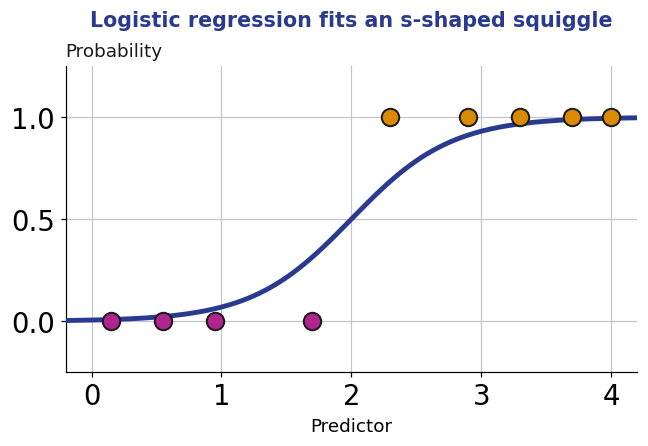

In [65]:
fig, ax = plt.subplots(figsize=(6.6, 4.4), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(-0.2, 4.2)
ax.set_ylim(-0.25, 1.25)
ax.set_xlabel("Predictor", fontsize=12)
ax.text(0, 1.02, "Probability", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)               # y label sits flat above the axis
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
x = np.linspace(-0.2, 4.2, 300)
ax.plot(x, 1 / (1 + np.exp(-2.6 * (x - 2.0))), color=MADRID, lw=3.2, zorder=3)
lo = np.array([0.15, 0.55, 0.95, 1.7])            # the zeros
hi = np.array([2.3, 2.9, 3.3, 3.7, 4.0])          # and the ones
ax.scatter(lo, np.zeros_like(lo), s=130, color="#B0248F", edgecolors=INK,
           lw=1.3, zorder=6)
ax.scatter(hi, np.ones_like(hi), s=130, color=ACCENT, edgecolors=INK,
           lw=1.3, zorder=6)
ax.set_title("Logistic regression fits an s-shaped squiggle", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### Learn It Once, Use It Everywhere

Gradient descent can optimize all of these, and much more.

So if we learn how it optimizes <b style="color:#73000A;">this one line</b>, we have learned the strategy that optimizes the squiggle, the clusters, and most of the other optimization problems in the field.


## A Simple Data Set

Weight on the horizontal axis, Height on the vertical.

| Weight | <b style="color:#73000A;">Height</b> |
|---|---|
| 0.5 | 1.4 |
| 2.3 | 1.9 |
| 2.9 | 3.2 |


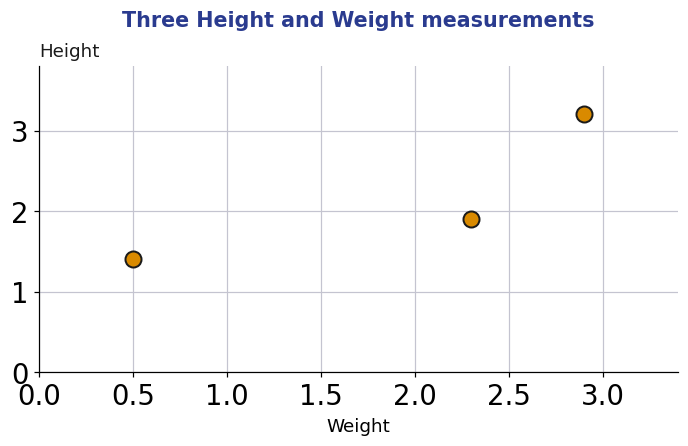

In [66]:
fig, ax = plt.subplots(figsize=(6.6, 4.4), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 3.4)
ax.set_ylim(0, 3.8)
ax.set_xlabel("Weight", fontsize=12)
ax.text(0, 1.02, "Height", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)               # y label sits flat above the axis
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.scatter(W, H, s=110, color=ACCENT, edgecolors=INK, lw=1.3, zorder=6)
ax.set_title("Three Height and Weight measurements", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### Fit a Line, Make a Prediction

If someone tells us they weigh $1.5$, put it through the line:

$$	ext{Height} = 0.95 + 0.64 	imes 1.5 = 0.95 + 0.96 = 1.91 pprox <b style="color:#73000A;">1.9</b>$$


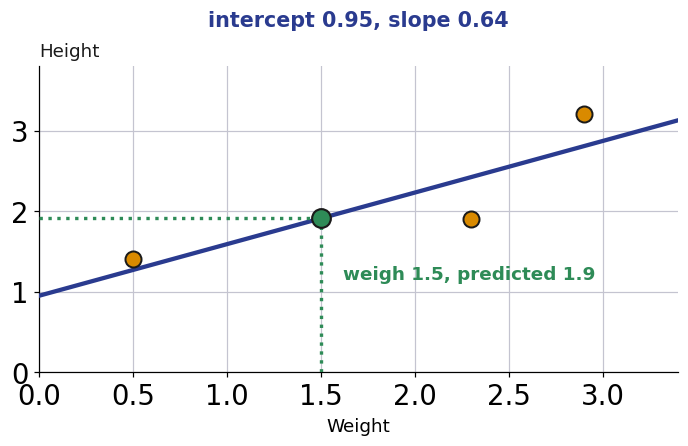

In [67]:
fig, ax = plt.subplots(figsize=(6.6, 4.4), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 3.4)
ax.set_ylim(0, 3.8)
ax.set_xlabel("Weight", fontsize=12)
ax.text(0, 1.02, "Height", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)               # y label sits flat above the axis
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
xs = np.array([0.0, 3.4])
ax.plot(xs, 0.95 + 0.64 * xs, color=MADRID, lw=2.8, zorder=3)
ax.scatter(W, H, s=110, color=ACCENT, edgecolors=INK, lw=1.3, zorder=6)
ax.plot([1.5, 1.5], [0, 0.95 + 0.64 * 1.5], color=STEM, lw=2.2, ls=":", zorder=4)
ax.plot([0, 1.5], [0.95 + 0.64 * 1.5] * 2, color=STEM, lw=2.2, ls=":", zorder=4)
ax.scatter([1.5], [0.95 + 0.64 * 1.5], s=150, color=STEM, edgecolors=INK,
           lw=1.4, zorder=7)
ax.annotate("weigh 1.5, predicted 1.9", (1.5, 1.91), xytext=(1.62, 1.15),
            fontsize=12, color=STEM, weight="bold")
ax.set_title("intercept 0.95, slope 0.64", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### The Intercept First

We will find the optimal values for the intercept and the slope. But we start with just the <b style="color:#73000A;">intercept</b>.

So plug in the least squares estimate for the slope, <b style="color:#73000A;">0.64</b>, and leave it there:

$$\text{Height} = \text{intercept} + 0.64 \times \text{Weight}$$

Once we understand how this works, we do both at once.


### Pick a Random Value for the Intercept

This is just an <b style="color:#73000A;">initial guess</b> that gives gradient descent something to improve upon.

We use $0$, but <b style="color:#73000A;">any number will do.</b>

$$\text{Height} = 0 + 0.64 \times \text{Weight}$$


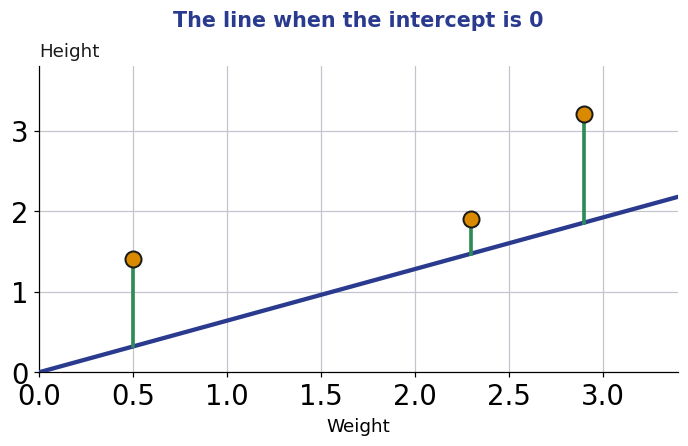

In [68]:
fig, ax = plt.subplots(figsize=(6.6, 4.4), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 3.4)
ax.set_ylim(0, 3.8)
ax.set_xlabel("Weight", fontsize=12)
ax.text(0, 1.02, "Height", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)               # y label sits flat above the axis
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
xs = np.array([0.0, 3.4])
ax.plot(xs, 0.0 + SLOPE * xs, color=MADRID, lw=2.8, zorder=3)
for wi, hi in zip(W, H):                       # residual stems
    ax.plot([wi, wi], [0.0 + SLOPE * wi, hi], color=STEM, lw=2.4, zorder=4)
ax.scatter(W, H, s=110, color=ACCENT, edgecolors=INK, lw=1.3, zorder=6)
ax.set_title("The line when the intercept is 0", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


## How Well Does This Line Fit?

We evaluate it with the <b style="color:#73000A;">sum of the squared residuals</b>.


### Terminology: Loss Function

<div style="border-left:6px solid #2E8B57; background:#eef7f1; border-radius:8px; padding:14px 20px; margin-top:10px;">
<b style="color:#2E8B57;">NOTE</b><br>
In machine learning lingo, the sum of the squared residuals is a type of <b style="color:#73000A;">Loss Function</b>.
</div>

Econometrics calls the same object the objective function or the criterion function.


### The First Residual

This point is a person with weight $0.5$ and height $1.4$.

The predicted height is the point on the line, so plug weight $= 0.5$ in:

$$\text{Predicted Height} = 0 + 0.64 \times 0.5 = \mathbf{0.32}$$

The residual is the difference between observed and predicted:

$$1.4 - 0.32 = \mathbf{1.1}$$


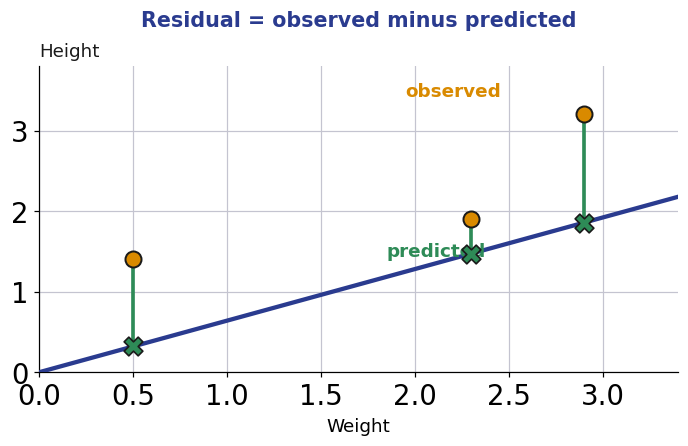

In [69]:
fig, ax = plt.subplots(figsize=(6.6, 4.4), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 3.4)
ax.set_ylim(0, 3.8)
ax.set_xlabel("Weight", fontsize=12)
ax.text(0, 1.02, "Height", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)               # y label sits flat above the axis
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
xs = np.array([0.0, 3.4])
ax.plot(xs, 0.0 + SLOPE * xs, color=MADRID, lw=2.8, zorder=3)
for wi, hi in zip(W, H):
    ax.plot([wi, wi], [SLOPE * wi, hi], color=STEM, lw=2.4, zorder=4)
    ax.scatter([wi], [SLOPE * wi], s=150, color=STEM, marker="X",
               edgecolors=INK, lw=1.1, zorder=7)                 # predicted
ax.scatter(W, H, s=110, color=ACCENT, edgecolors=INK, lw=1.3, zorder=6)
ax.annotate("observed", (W[2], H[2]), xytext=(W[2] - 0.95, H[2] + 0.22),
            fontsize=12, color=ACCENT, weight="bold")
ax.annotate("predicted", (W[2], SLOPE * W[2]), xytext=(W[2] - 1.05, SLOPE * W[2] - 0.42),
            fontsize=12, color=STEM, weight="bold")
ax.set_title("Residual = observed minus predicted", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### Square Them and Add Them Up

Work each residual out:
$$
\text{Height}_i-
\left(\underbrace{\text{intercept}}_{=\,0}
+0.64\times\text{Weight}_i\right)
=\hat{\epsilon}_i
$$

$$1.4 - 0.64 \times 0.5 = 1.4 - 0.32 = 1.08 \approx \mathbf{1.1}$$

$$1.9 - 0.64 \times 2.3 = 1.9 - 1.472 = 0.428 \approx \mathbf{0.4}$$

$$3.2 - 0.64 \times 2.9 = 3.2 - 1.856 = 1.344 \approx \mathbf{1.3}$$

Then square and add:

$$1.1^2 + 0.4^2 + 1.3^2 = 1.21 + 0.16 + 1.69 = \mathbf{3.1}$$


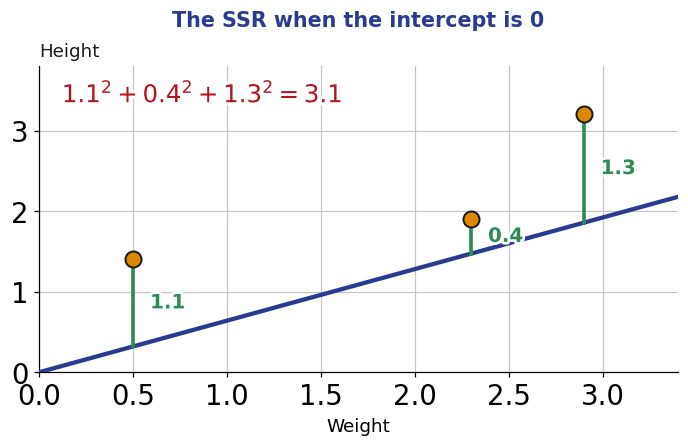

In [95]:
import matplotlib.patheffects as pe

BUF = [pe.withStroke(linewidth=3.5, foreground="white")]

fig, ax = plt.subplots(figsize=(6.6, 4.4), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 3.4)
ax.set_ylim(0, 3.8)
ax.set_xlabel("Weight", fontsize=12)
ax.text(0, 1.02, "Height", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)  # y label sits flat above the axis
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

r = np.round(H - SLOPE * W, 1)  # the rounded residuals

xs = np.array([0.0, 3.4])
ax.plot(xs, 0.0 + SLOPE * xs, color=MADRID, lw=2.8, zorder=3)

for wi, hi in zip(W, H):
    ax.plot([wi, wi], [SLOPE * wi, hi], color=STEM, lw=2.4, zorder=4)
    ax.text(wi + 0.09, (hi + SLOPE * wi) / 2.0, "%.1f" % (hi - SLOPE * wi),
            fontsize=13, color=STEM, weight="bold", va="center",
            zorder=7, path_effects=BUF)

ax.scatter(W, H, s=110, color=ACCENT, edgecolors=INK, lw=1.3, zorder=6)

ax.text(0.12, 3.35,
        "$%.1f^2 + %.1f^2 + %.1f^2 = %.1f$"
        % (r[0], r[1], r[2], round(float(np.sum(r ** 2)), 1)),
        fontsize=16, color=FITLINE, weight="bold", zorder=7,
        path_effects=[pe.withStroke(linewidth=4, foreground="white")])

ax.set_title("The SSR when the intercept is 0", fontsize=13.5,
             color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()

## Now Plot That Value

Sum of the squared residuals on the vertical axis, different values for the <b style="color:#73000A;">intercept</b> on the horizontal.

This point is the SSR when the intercept equals $0$.


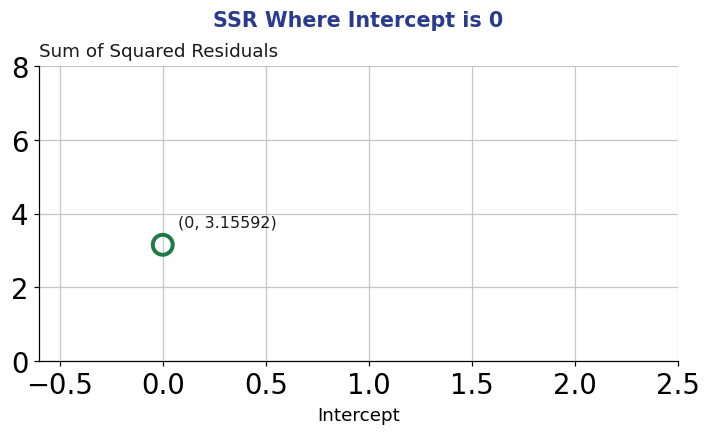

In [92]:

grid = np.linspace(BLO, BHI, 300)
curve = np.array([ssr(x) for x in grid])

fig, ax = plt.subplots(figsize=(6.6, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)

ax.set_xlim(BLO, BHI)
ax.set_ylim(curve.min() - 0.45, curve.max() + 0.35)

ax.set_xlabel("Intercept", fontsize=12)

ax.text(
    0, 1.02, "Sum of Squared Residuals",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=12,
    color=INK
)

for s in ("top", "right"):
    ax.spines[s].set_visible(False)

# One intercept tried
b = 0.0
y = ssr(b)

# Circle the point
ax.scatter(
    [b], [y],
    s=170,
    facecolors="none",
    edgecolors=RING,
    lw=2.6,
    zorder=6
)

# Label the point with its actual coordinates
ax.annotate(
    f"({b:g}, {y:g})",
    xy=(b, y),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=10.5,
    color=INK,
    ha="left",
    va="bottom"
)

ax.set_title(
    "SSR Where Intercept is 0",
    fontsize=13.5,
    color=MADRID,
    weight="bold",
    pad=26
)

fig.tight_layout()
plt.show()



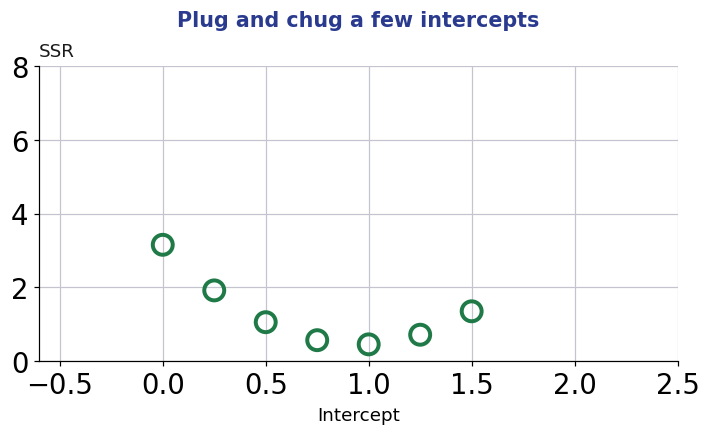

In [72]:
grid = np.linspace(BLO, BHI, 300)
curve = np.array([ssr(x) for x in grid])

fig, ax = plt.subplots(figsize=(6.6, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(BLO, BHI)
ax.set_ylim(curve.min() - 0.45, curve.max() + 0.35)
ax.set_xlabel("Intercept", fontsize=12)
ax.text(0, 1.02, "SSR", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for b in [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]:                                   # intercepts tried
    ax.scatter([b], [ssr(b)], s=170, facecolors="none",
               edgecolors=RING, lw=2.6, zorder=6)
ax.set_title("Plug and chug a few intercepts", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### The Slow and Painful Method

A slow and painful way to find the smallest sum of the squared residuals is to <b style="color:#73000A;">plug and chug</b> a bunch more values for the intercept.

Do not despair. Gradient descent is <b style="color:#73000A;">way more efficient</b>.


### Big Steps Far Away, Baby Steps Close

Gradient descent does only <b style="color:#73000A;">a few calculations</b> far from the optimal solution, and increases the number of calculations closer to it.

In other words, it identifies the optimal value by taking <b style="color:#73000A;">big steps</b> when it is far away, and <b style="color:#73000A;">baby steps</b> when it is close.


## Write the Residuals Out in Full

For the first person, weight $0.5$:

$$\big(1.4 - (\text{intercept} + 0.64 \times 0.5)\big)^2$$

The second, weight $2.3$, and the third, weight $2.9$:

$$\big(1.9 - (\text{intercept} + 0.64 \times 2.3)\big)^2 \qquad \big(3.2 - (\text{intercept} + 0.64 \times 2.9)\big)^2$$

Now we can plug in <b style="color:#73000A;">any value for the intercept</b> and get the sum of the squared residuals.


### So We Have an Equation for the Curve

And once we have the equation, we can take its derivative and find the <b style="color:#73000A;">slope at any value for the intercept</b>.


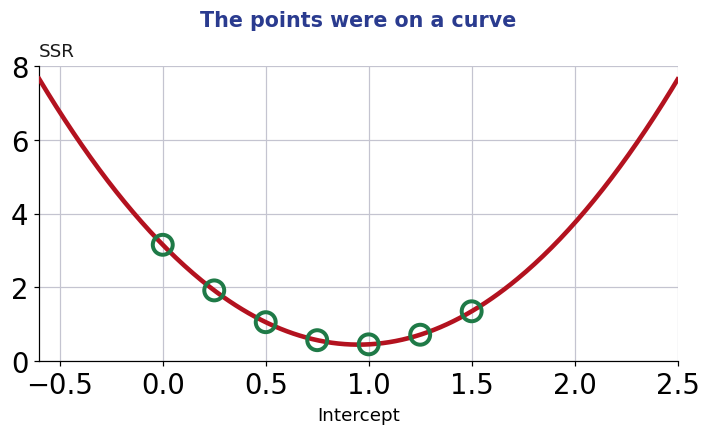

In [73]:
grid = np.linspace(BLO, BHI, 300)
curve = np.array([ssr(x) for x in grid])

fig, ax = plt.subplots(figsize=(6.6, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(BLO, BHI)
ax.set_ylim(curve.min() - 0.45, curve.max() + 0.35)
ax.set_xlabel("Intercept", fontsize=12)
ax.text(0, 1.02, "SSR", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.plot(grid, curve, color=FITLINE, lw=3.0, zorder=3)
for b in [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]:                                   # intercepts tried
    ax.scatter([b], [ssr(b)], s=170, facecolors="none",
               edgecolors=RING, lw=2.6, zorder=6)
ax.set_title("The points were on a curve", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### The Derivative Has Three Parts

The SSR is three squared residuals added together, so its derivative is three derivatives added together.

Take the first one on its own. For the person who weighs $0.5$:

$$\big(1.4 - (\text{intercept} + 0.64 \times 0.5)\big)^2$$


### Name the Inside and the Outside

The bracket is just the <b style="color:#73000A;">residual</b> for that person. For the one who weighs $0.5$:

$$\text{Residual} = 1.4 - (\text{intercept} + 0.64 \times 0.5)$$

So the first part of the SSR is $\text{Residual}^2$, and the <b style="color:#73000A;">chain rule</b> says

$$\frac{d}{d\,\text{intercept}}\left(\text{Residual}^2\right) = \frac{d\,\text{Residual}^2}{d\,\text{Residual}} \times \frac{d\,\text{Residual}}{d\,\text{intercept}}$$

Two easy derivatives instead of one awkward one.

### The Outside Piece

Power rule on $\text{Residual}^2$: bring the exponent down, drop it by one.

$$\frac{d\,\text{Residual}^2}{d\,\text{Residual}} = 2\,\text{Residual}^{\,2-1} = \mathbf{2 \times \text{Residual}}$$

The intercept has not entered yet.

### The Inside Piece

Multiply the bracket out so every term is visible:

$$\text{Residual} = 1.4 - \text{intercept} - 0.64 \times 0.5 = 1.4 - \text{intercept} - 0.32$$

Now differentiate term by term with respect to the intercept:

$$\frac{d}{d\,\text{intercept}}(1.4) = 0 \qquad \frac{d}{d\,\text{intercept}}(-\text{intercept}) = -1 \qquad \frac{d}{d\,\text{intercept}}(-0.32) = 0$$

$$\frac{d\,\text{Residual}}{d\,\text{intercept}} = 0 - 1 - 0 = \mathbf{-1}$$

### Multiply the Two Pieces

$$\frac{d}{d\,\text{intercept}}\left(\text{Residual}^2\right) = 2 \times \text{Residual} \times (-1) = -2 \times \text{Residual}$$

Write the residual back out in full:

$$= -2\big(1.4 - (\text{intercept} + 0.64 \times 0.5)\big)$$

The first part is done.

### The Second Part, Same Three Steps

The person who weighs $2.3$ has residual

$$\text{Residual}_2 = 1.9 - (\text{intercept} + 0.64 \times 2.3) = 1.9 - \text{intercept} - 1.472$$

Outside, then inside:

$$\frac{d\,\text{Residual}_2^{\,2}}{d\,\text{Residual}_2} = 2 \times \text{Residual}_2 \qquad \frac{d\,\text{Residual}_2}{d\,\text{intercept}} = 0 - 1 - 0 = -1$$

$$2 \times \text{Residual}_2 \times (-1) = -2\big(1.9 - (\text{intercept} + 1.472)\big)$$

### And the Third

The person who weighs $2.9$ has residual

$$\text{Residual}_3 = 3.2 - (\text{intercept} + 0.64 \times 2.9) = 3.2 - \text{intercept} - 1.856$$

Outside, then inside:

$$\frac{d\,\text{Residual}_3^{\,2}}{d\,\text{Residual}_3} = 2 \times \text{Residual}_3 \qquad \frac{d\,\text{Residual}_3}{d\,\text{intercept}} = 0 - 1 - 0 = -1$$

$$2 \times \text{Residual}_3 \times (-1) = -2\big(3.2 - (\text{intercept} + 1.856)\big)$$

### All Three Together

$$\frac{d\,\text{SSR}}{d\,\text{intercept}} = -2\big(1.4 - (\text{intercept} + 0.32)\big) -2\big(1.9 - (\text{intercept} + 1.472)\big) -2\big(3.2 - (\text{intercept} + 1.856)\big)$$

Every term has the same shape: <b style="color:#73000A;">minus two times that point's residual.</b>


In [74]:
W = np.array([0.5, 2.3, 2.9])          # the three weights
H = np.array([1.4, 1.9, 3.2])          # and the three heights
intercept, slope = 0.0, 0.64

residuals = H - (intercept + slope * W)
print("residuals            ", np.round(residuals, 3))
print("-2 x each residual   ", np.round(-2 * residuals, 3))
print("summed over the three", round(float(np.sum(-2 * residuals)), 3))


residuals             [1.08  0.428 1.344]
-2 x each residual    [-2.16  -0.856 -2.688]
summed over the three -5.704


### Least Squares Solves; Gradient Descent Walks

<div style="border-left:6px solid #2E8B57; background:#eef7f1; border-radius:8px; padding:14px 20px; margin-top:10px;">
<b style="color:#2E8B57;">NOTE</b><br>
If we were using <b style="color:#73000A;">least squares</b> to solve for the optimal value for the intercept, we would simply find where the <b style="color:#73000A;">slope of the curve equals zero</b>.<br><br>In contrast, gradient descent finds the minimum by <b style="color:#73000A;">taking steps from an initial guess</b> until it reaches the best value.<br><br>This makes it very useful when it is <b style="color:#73000A;">not possible to solve for where the derivative equals zero</b>, and it is why gradient descent can be used in so many different situations.
</div>


## Plug In the Starting Value

We set the intercept to $0$, so put $0$ into the derivative and do the arithmetic one term at a time:

$$\frac{d\,\text{SSR}}{d\,\text{intercept}} = -2\big(1.4 - (0 + 0.64 \times 0.5)\big) -2\big(1.9 - (0 + 0.64 \times 2.3)\big) -2\big(3.2 - (0 + 0.64 \times 2.9)\big)$$

$$= -2(1.08) - 2(0.428) - 2(1.344) = -2.16 - 0.856 - 2.688 = \mathbf{-5.7}$$

So when the intercept equals $0$, the slope of the curve equals $-5.7$.


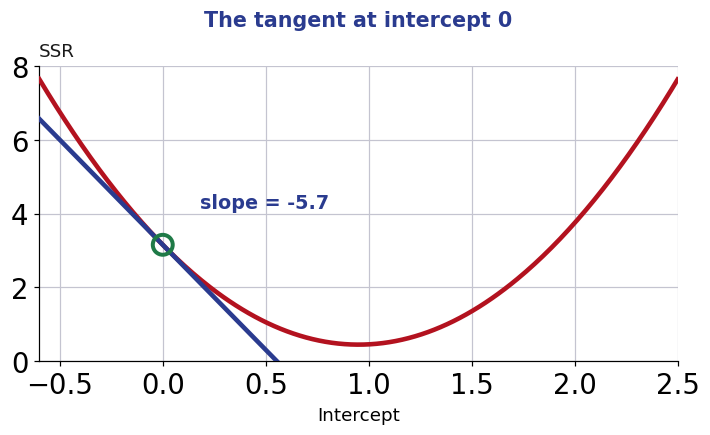

In [75]:
grid = np.linspace(BLO, BHI, 300)
curve = np.array([ssr(x) for x in grid])

fig, ax = plt.subplots(figsize=(6.6, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(BLO, BHI)
ax.set_ylim(curve.min() - 0.45, curve.max() + 0.35)
ax.set_xlabel("Intercept", fontsize=12)
ax.text(0, 1.02, "SSR", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.plot(grid, curve, color=FITLINE, lw=3.0, zorder=3)
b0 = 0.0                                        # tangent touches here
g = deriv(b0)
xs = np.array([b0 - 0.62, b0 + 0.62])
ax.plot(xs, ssr(b0) + g * (xs - b0), color=MADRID, lw=3.0, zorder=4)
ax.annotate("slope = %.1f" % g, (b0, ssr(b0)),
            xytext=(b0 + 0.18, ssr(b0) + 1.0), fontsize=12.5,
            color=MADRID, weight="bold")
for b in [0.0]:                                   # intercepts tried
    ax.scatter([b], [ssr(b)], s=170, facecolors="none",
               edgecolors=RING, lw=2.6, zorder=6)
ax.set_title("The tangent at intercept 0", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### Closer to the Answer, Closer to Zero

The closer we get to the optimal value for the intercept, the closer the slope of the curve gets to <b style="color:#73000A;">zero</b>.

So when the slope is close to zero, take <b style="color:#73000A;">baby steps</b>, because we are close.

And when the slope is far from zero, take <b style="color:#73000A;">big steps</b>, because we are far.


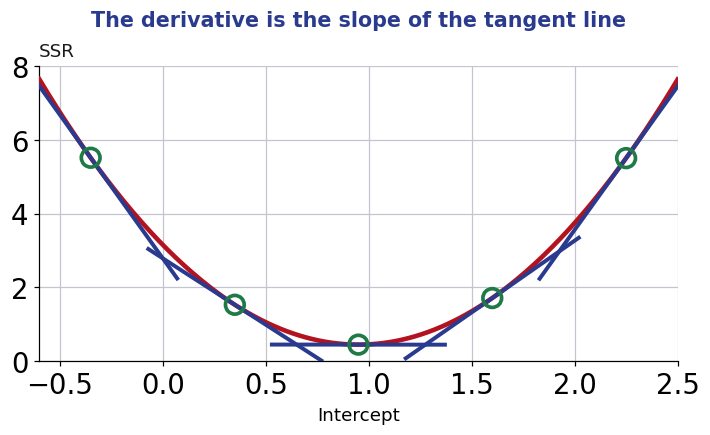

In [76]:
grid = np.linspace(BLO, BHI, 300)
curve = np.array([ssr(x) for x in grid])

fig, ax = plt.subplots(figsize=(6.6, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(BLO, BHI)
ax.set_ylim(curve.min() - 0.45, curve.max() + 0.35)
ax.set_xlabel("Intercept", fontsize=12)
ax.text(0, 1.02, "SSR", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.plot(grid, curve, color=FITLINE, lw=3.0, zorder=3)
for b in (-0.35, 0.35, 0.95, 1.6, 2.25):          # a tangent at each
    g = deriv(b)
    xs = np.array([b - 0.42, b + 0.42])
    ax.plot(xs, ssr(b) + g * (xs - b), color=MADRID, lw=2.6, zorder=4)
    ax.scatter([b], [ssr(b)], s=150, facecolors="none", edgecolors=RING,
               lw=2.4, zorder=6)
ax.set_title("The derivative is the slope of the tangent line", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### But Not Too Big

If we take a <b style="color:#73000A;">super huge step</b>, we would increase the sum of the squared residuals.

So the size of the step should be related to the slope, but we need to make sure the big step is not too big.


### Step Size = Slope $\times$ Learning Rate

Gradient descent determines the step size by multiplying the slope by a small number called the <b style="color:#73000A;">learning rate</b>.

$$\text{Step Size} = -5.7 \times 0.1 = \mathbf{-0.57}$$


### The New Intercept

$$\text{New intercept} = \text{Old intercept} - \text{Step Size} = 0 - (-0.57) = \mathbf{0.57}$$

In one big step we moved much closer to the optimal value.


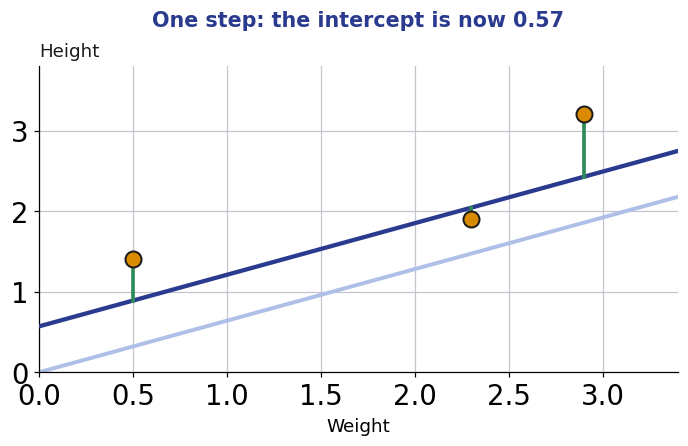

In [77]:
fig, ax = plt.subplots(figsize=(6.6, 4.4), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 3.4)
ax.set_ylim(0, 3.8)
ax.set_xlabel("Weight", fontsize=12)
ax.text(0, 1.02, "Height", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)               # y label sits flat above the axis
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
xs = np.array([0.0, 3.4])
ax.plot(xs, 0.0 + SLOPE * xs, color=GHOST, lw=2.6, zorder=2)
xs = np.array([0.0, 3.4])
ax.plot(xs, 0.57 + SLOPE * xs, color=MADRID, lw=2.8, zorder=3)
for wi, hi in zip(W, H):                       # residual stems
    ax.plot([wi, wi], [0.57 + SLOPE * wi, hi], color=STEM, lw=2.4, zorder=4)
ax.scatter(W, H, s=110, color=ACCENT, edgecolors=INK, lw=1.3, zorder=6)
ax.set_title("One step: the intercept is now 0.57", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### Take Another Step

Go back to the derivative and put the new intercept, $0.57$, in:

$$-2\big(1.4 - (0.57 + 0.32)\big) - 2\big(1.9 - (0.57 + 1.472)\big) - 2\big(3.2 - (0.57 + 1.856)\big)$$

$$= -2(0.51) - 2(-0.142) - 2(0.774) = -1.02 + 0.284 - 1.548 = \mathbf{-2.3}$$

$$\text{Step Size} = -2.3 \times 0.1 = -0.23 \qquad \text{New intercept} = 0.57 - (-0.23) = \mathbf{0.8}$$


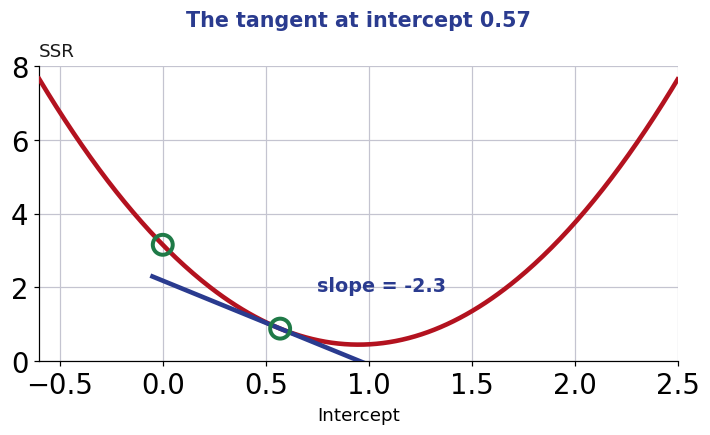

In [78]:
grid = np.linspace(BLO, BHI, 300)
curve = np.array([ssr(x) for x in grid])

fig, ax = plt.subplots(figsize=(6.6, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(BLO, BHI)
ax.set_ylim(curve.min() - 0.45, curve.max() + 0.35)
ax.set_xlabel("Intercept", fontsize=12)
ax.text(0, 1.02, "SSR", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.plot(grid, curve, color=FITLINE, lw=3.0, zorder=3)
b0 = 0.57                                        # tangent touches here
g = deriv(b0)
xs = np.array([b0 - 0.62, b0 + 0.62])
ax.plot(xs, ssr(b0) + g * (xs - b0), color=MADRID, lw=3.0, zorder=4)
ax.annotate("slope = %.1f" % g, (b0, ssr(b0)),
            xytext=(b0 + 0.18, ssr(b0) + 1.0), fontsize=12.5,
            color=MADRID, weight="bold")
for b in [0.0, 0.57]:                                   # intercepts tried
    ax.scatter([b], [ssr(b)], s=170, facecolors="none",
               edgecolors=RING, lw=2.6, zorder=6)
ax.set_title("The tangent at intercept 0.57", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### And Another

At an intercept of $0.8$:

$$-2(0.28) - 2(-0.372) - 2(0.544) = -0.56 + 0.744 - 1.088 = \mathbf{-0.9}$$

$$\text{Step Size} = -0.09 \qquad \text{New intercept} = \mathbf{0.89}$$

Then $0.92$, then $0.94$, then $\mathbf{0.95}$. Each step is smaller than the last.


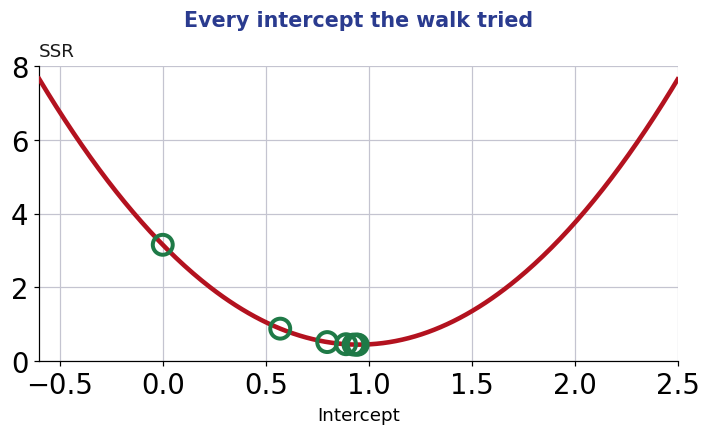

In [79]:
grid = np.linspace(BLO, BHI, 300)
curve = np.array([ssr(x) for x in grid])

fig, ax = plt.subplots(figsize=(6.6, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(BLO, BHI)
ax.set_ylim(curve.min() - 0.45, curve.max() + 0.35)
ax.set_xlabel("Intercept", fontsize=12)
ax.text(0, 1.02, "SSR", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.plot(grid, curve, color=FITLINE, lw=3.0, zorder=3)
b, walk = 0.0, [0.0]                              # six steps, lr 0.1
for _ in range(6):
    b = b - 0.1 * deriv(b)
    walk.append(b)
for b in walk:
    ax.scatter([b], [ssr(b)], s=170, facecolors="none", edgecolors=RING,
               lw=2.6, zorder=6)
ax.set_title("Every intercept the walk tried", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### Six Steps, and Least Squares Agrees

After six steps the gradient descent estimate for the intercept is <b style="color:#73000A;">0.95</b>.

The least squares estimate is <b style="color:#73000A;">also 0.95</b>.

So we know gradient descent did its job. But without a gold standard to compare against, how does it know when to stop?


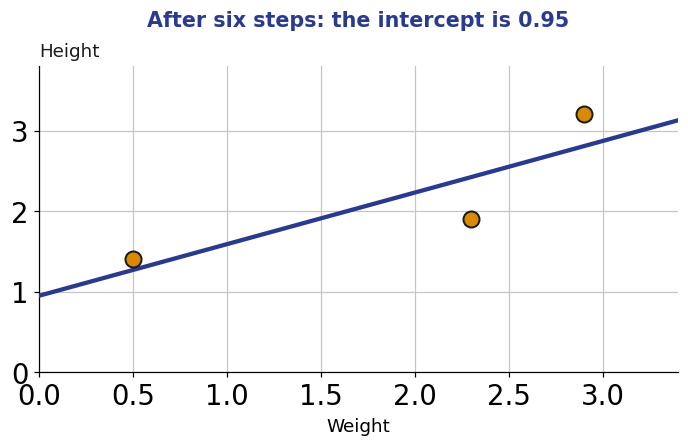

In [80]:
fig, ax = plt.subplots(figsize=(6.6, 4.4), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 3.4)
ax.set_ylim(0, 3.8)
ax.set_xlabel("Weight", fontsize=12)
ax.text(0, 1.02, "Height", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)               # y label sits flat above the axis
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
xs = np.array([0.0, 3.4])
ax.plot(xs, 0.95 + SLOPE * xs, color=MADRID, lw=2.8, zorder=3)
ax.scatter(W, H, s=110, color=ACCENT, edgecolors=INK, lw=1.3, zorder=6)
ax.set_title("After six steps: the intercept is 0.95", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### How Does It Know to Stop?

Gradient descent stops when the <b style="color:#73000A;">step size is very close to zero</b>, which happens when the slope is very close to zero. In practice the minimum step size is <b style="color:#73000A;">0.001</b> or smaller.

If the slope were $0.009$:

$$0.009 \times 0.1 = 0.0009$$

which is smaller than $0.001$, so it stops.

It also gives up after a <b style="color:#73000A;">maximum number of steps</b>, in practice $1{,}000$ or greater.


## Review: What We Just Did

1. Chose the sum of the squared residuals as the <b style="color:#73000A;">loss function</b>
2. Took the <b style="color:#73000A;">derivative of the loss function</b>
3. Picked a <b style="color:#73000A;">random value</b> for the intercept, here $0$
4. Calculated the derivative at that value, put the slope into the <b style="color:#73000A;">step size calculation</b>, and calculated the new intercept
5. Plugged the new intercept back into the derivative and <b style="color:#73000A;">repeated until the step size was close to zero</b>


## Now the Intercept and the Slope

Same loss function, both parameters free:

$$\text{Height} = \text{intercept} + \text{slope} \times \text{Weight}$$


### The Loss Is Now a Surface

One axis for the sum of the squared residuals, one for different values of the slope, and one for different values of the intercept.

We want the pair that gives the <b style="color:#73000A;">minimum SSR</b>.


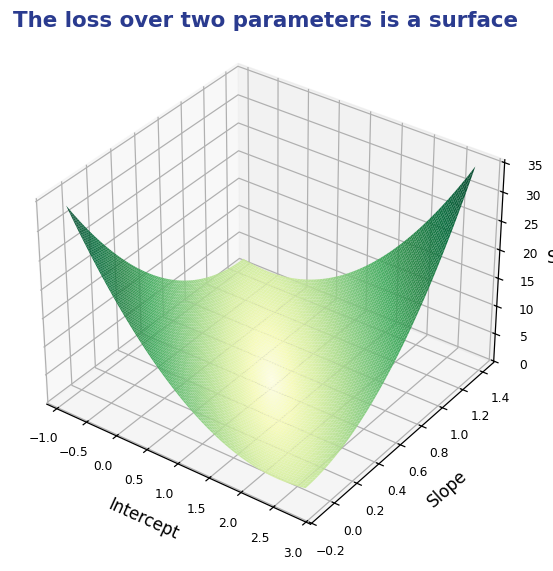

In [81]:
from matplotlib.colors import PowerNorm

b = np.linspace(-0.9, 2.8, 80)
m = np.linspace(-0.1, 1.4, 80)
B, M = np.meshgrid(b, m)
Z = np.zeros_like(B)
for wi, hi in zip(W, H):                          # SSR over both parameters
    Z += (hi - (B + M * wi)) ** 2

fig = plt.figure(figsize=(7.2, 5.4), dpi=110)
fig.patch.set_facecolor("white")
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(B, M, Z, cmap="YlGn", edgecolor="none", alpha=0.95,
                rstride=1, cstride=1, antialiased=True,
                norm=PowerNorm(0.45, vmin=Z.min(), vmax=Z.max()))
ax.set_xlabel("Intercept", fontsize=11, labelpad=6)
ax.set_ylabel("Slope", fontsize=11, labelpad=6)
ax.set_zlabel("SSR", fontsize=11, labelpad=4)
ax.set_title("The loss over two parameters is a surface", fontsize=14,
             color=MADRID, weight="bold", pad=6)
ax.view_init(elev=34, azim=-54)
ax.tick_params(labelsize=8)
fig.tight_layout()
plt.show()


### With Respect to the Intercept

Same three steps, with $\text{slope}$ where $0.64$ used to be.

$$\text{Residual} = \text{Height} - (\text{intercept} + \text{slope} \times \text{Weight}) = \text{Height} - \text{intercept} - \text{slope} \times \text{Weight}$$

Outside: $\dfrac{d\,\text{Residual}^2}{d\,\text{Residual}} = 2 \times \text{Residual}$. Inside, term by term:

$$\frac{d(\text{Height})}{d\,\text{intercept}} = 0 \qquad \frac{d(-\text{intercept})}{d\,\text{intercept}} = -1 \qquad \frac{d(-\text{slope} \times \text{Weight})}{d\,\text{intercept}} = 0$$

$$\frac{d\,\text{Residual}}{d\,\text{intercept}} = -1 \quad\Longrightarrow\quad 2 \times \text{Residual} \times (-1) = -2\big(\text{Height} - (\text{intercept} + \text{slope} \times \text{Weight})\big)$$

### With Respect to the Slope: Only the Inside Changes

The outside is identical: $\dfrac{d\,\text{Residual}^2}{d\,\text{Residual}} = 2 \times \text{Residual}$.

Differentiate the inside by the <b style="color:#73000A;">slope</b> this time:

$$\frac{d(\text{Height})}{d\,\text{slope}} = 0 \qquad \frac{d(-\text{intercept})}{d\,\text{slope}} = 0 \qquad \frac{d(-\text{slope} \times \text{Weight})}{d\,\text{slope}} = -\text{Weight}$$

$$\frac{d\,\text{Residual}}{d\,\text{slope}} = 0 - 0 - \text{Weight} = \mathbf{-\text{Weight}}$$

### Multiply Them

$$2 \times \text{Residual} \times (-\text{Weight}) = -2 \times \text{Weight} \times \big(\text{Height} - (\text{intercept} + \text{slope} \times \text{Weight})\big)$$

For the person who weighs $0.5$, the inside derivative is $-0.5$, so that term is

$$-2 \times 0.5 \times \big(1.4 - (\text{intercept} + \text{slope} \times 0.5)\big)$$

The $0.5$ stays out front rather than being multiplied into the $2$, as a reminder that it is <b style="color:#73000A;">that person's Weight</b>.

### Two Derivatives Have a Name

<div style="border-left:6px solid #2E8B57; background:#eef7f1; border-radius:8px; padding:14px 20px; margin-top:10px;">
<b style="color:#2E8B57;">NOTE</b><br>
When you have two or more derivatives of the same function, they are called a <b style="color:#73000A;">gradient</b>.<br><br>We use the gradient to <b style="color:#73000A;">descend to the lowest point in the loss function</b>, which here is the sum of the squared residuals.<br><br>And that is why the algorithm is called <b style="color:#73000A;">Gradient Descent</b>.
</div>


### Start at Intercept 0, Slope 1

Pick a random number for each: intercept $= 0$ and slope $= 1$. The three residuals are

$$1.4 - (0 + 1 \times 0.5) = 0.9 \qquad 1.9 - (0 + 1 \times 2.3) = -0.4 \qquad 3.2 - (0 + 1 \times 2.9) = 0.3$$

so the two derivatives are

$$\frac{d\,\text{SSR}}{d\,\text{intercept}} = -2(0.9 - 0.4 + 0.3) = \mathbf{-1.6}$$

$$\frac{d\,\text{SSR}}{d\,\text{slope}} = -2\big(0.5(0.9) + 2.3(-0.4) + 2.9(0.3)\big) = -2(0.45 - 0.92 + 0.87) = \mathbf{-0.8}$$


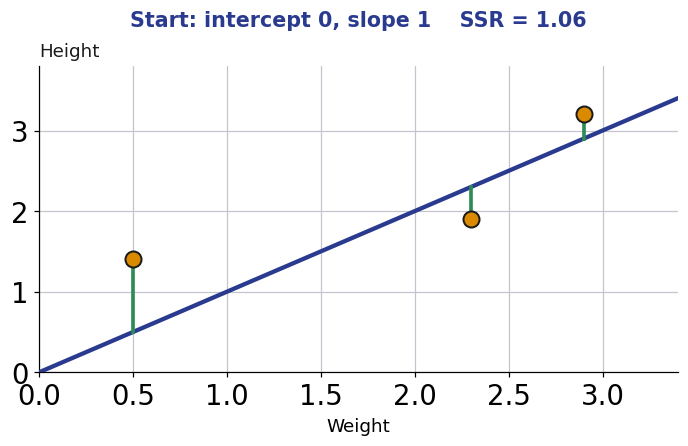

In [82]:
fig, ax = plt.subplots(figsize=(6.6, 4.4), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 3.4)
ax.set_ylim(0, 3.8)
ax.set_xlabel("Weight", fontsize=12)
ax.text(0, 1.02, "Height", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)               # y label sits flat above the axis
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
xs = np.array([0.0, 3.4])
ax.plot(xs, 0.0 + 1.0 * xs, color=MADRID, lw=2.8, zorder=3)
for wi, hi in zip(W, H):
    ax.plot([wi, wi], [0.0 + 1.0 * wi, hi], color=STEM, lw=2.4, zorder=4)
ax.scatter(W, H, s=110, color=ACCENT, edgecolors=INK, lw=1.3, zorder=6)
ax.set_title("Start: intercept 0, slope 1    SSR = %.2f" % ssr(0.0, 1.0), fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### Why the Smaller Learning Rate?

<div style="border-left:6px solid #2E8B57; background:#eef7f1; border-radius:8px; padding:14px 20px; margin-top:10px;">
<b style="color:#2E8B57;">NOTE</b><br>
The larger learning rate we used in the first example <b style="color:#73000A;">does not work this time</b>. Even after a bunch of steps, gradient descent <b style="color:#73000A;">does not arrive at the correct answer</b>.<br><br>This means gradient descent can be <b style="color:#73000A;">very sensitive to the learning rate</b>.<br><br>The good news: in practice a reasonable learning rate can be determined automatically, by <b style="color:#73000A;">starting large and getting smaller with each step</b>. So in theory you should not have to worry too much about it.
</div>


### Take the First Step

With a learning rate of $0.01$:

$$\text{Step}_{\text{intercept}} = -1.6 \times 0.01 = -0.016 \qquad \text{Step}_{\text{slope}} = -0.8 \times 0.01 = -0.008$$

$$\text{New intercept} = 0 - (-0.016) = \mathbf{0.016} \qquad \text{New slope} = 1 - (-0.008) = \mathbf{1.008}$$

Barely moved. That's what a learning rate of $0.01$ does.


### Then Repeat

Keep going until the step sizes are very small, or we reach the maximum number of steps. The best fitting line has

$$\text{intercept} = \mathbf{0.95} \qquad \text{slope} = \mathbf{0.64}$$

the same values least squares gives.


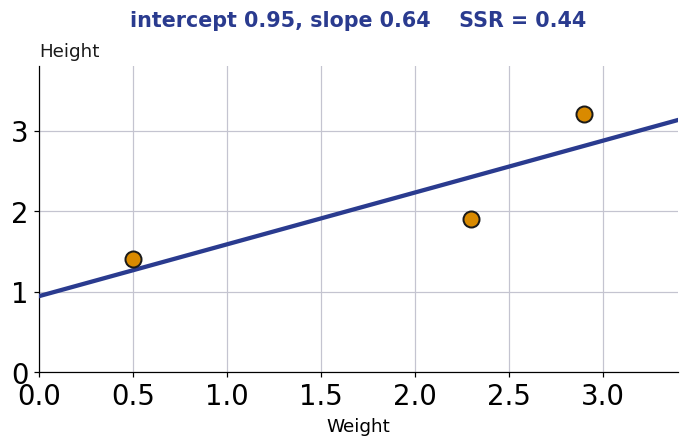

In [83]:
fig, ax = plt.subplots(figsize=(6.6, 4.4), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 3.4)
ax.set_ylim(0, 3.8)
ax.set_xlabel("Weight", fontsize=12)
ax.text(0, 1.02, "Height", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)               # y label sits flat above the axis
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
xs = np.array([0.0, 3.4])
ax.plot(xs, 0.945 + 0.6426 * xs, color=MADRID, lw=2.8, zorder=3)
ax.scatter(W, H, s=110, color=ACCENT, edgecolors=INK, lw=1.3, zorder=6)
ax.set_title("intercept 0.95, slope 0.64    SSR = %.2f" % ssr(0.945, 0.6426), fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### More Parameters Changes Nothing

If we had more parameters we would just <b style="color:#73000A;">take more derivatives</b>, and everything else stays the same.

<div style="border-left:6px solid #2E8B57; background:#eef7f1; border-radius:8px; padding:14px 20px; margin-top:10px;">
<b style="color:#2E8B57;">NOTE</b><br>
The sum of the squared residuals is just one type of <b style="color:#73000A;">loss function</b>. There are many others that work with other types of data, and regardless of which one you use, <b style="color:#73000A;">gradient descent works the same way</b>.
</div>


## The Gradient Descent Algorithm

1. Take the <b style="color:#73000A;">derivative</b> of the loss function for each parameter in it. In fancy machine learning lingo, take the <b style="color:#73000A;">gradient</b> of the loss function
2. Pick <b style="color:#73000A;">random values</b> for the parameters
3. Plug the parameter values into the derivatives, ahem, the gradient
4. Calculate the <b style="color:#73000A;">step sizes</b>
5. Calculate the <b style="color:#73000A;">new parameters</b>

Then go back to step 3 and repeat until the step size is very small, or you reach the maximum number of steps.


## Three Points Was Easy

In our example we only had three data points, so the math did not take very long.

But when you have <b style="color:#73000A;">millions of data points</b> it can take a long time.


### What That Costs on a Real Problem

A logistic regression using <b style="color:#73000A;">23,000 genes</b> to predict whether someone has a disease means 23,000 derivatives to plug data into.

With <b style="color:#73000A;">1 million samples</b>, each derivative needs a million terms:

$$23{,}000 \times 1{,}000{,}000 = \mathbf{23\text{ billion terms}} \quad \text{per step}$$

And it is common to take at least $1{,}000$ steps:

$$23{,}000{,}000{,}000 	imes 1{,}000 = <b style="color:#73000A;">23 trillion terms</b>$$

For big data, gradient descent is slow.


### Stochastic Gradient Descent

Stochastic gradient descent randomly picks <b style="color:#73000A;">one sample for each step</b> and uses just that one sample to calculate the derivatives.

In our three-point example that cuts the terms computed by a factor of three. With a million samples it cuts them by <b style="color:#73000A;">a factor of a million</b>.


### It Really Pays When the Data Is Redundant

It is especially useful when there are <b style="color:#73000A;">redundancies in the data</b>.

Here are twelve measurements, but they clump into three groups. A point drawn from one group tells you most of what the others in that group would have told you.


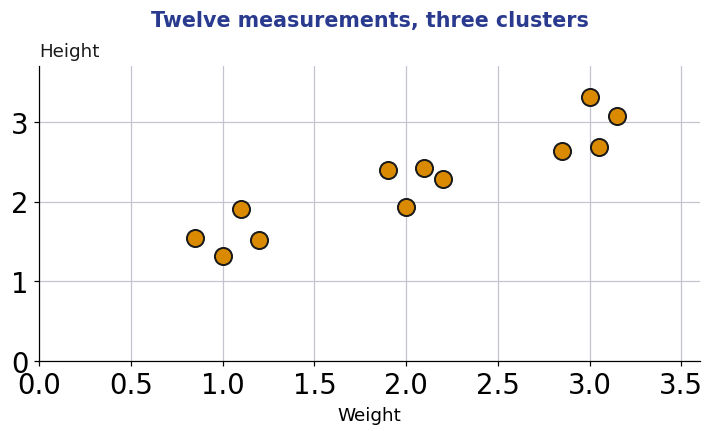

In [84]:
fig, ax = plt.subplots(figsize=(6.8, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 3.6)
ax.set_ylim(0, 3.7)
ax.set_xlabel("Weight", fontsize=12)
ax.text(0, 1.02, "Height", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.scatter(CW, CH, s=125, color=ACCENT, edgecolors=INK, lw=1.3, zorder=5)
ax.set_title("Twelve measurements, three clusters", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### Start, Then Pick One

Start with intercept $= 0$ and slope $= 1$, then randomly pick a single point, here the one at weight $3$, height $3.3$. Its residual is

$$3.3 - (0 + 1 \times 3) = \mathbf{0.3}$$

and that one point gives both derivatives:

$$\frac{d\,\text{SSR}}{d\,\text{intercept}} = -2(0.3) = -0.6 \qquad \frac{d\,\text{SSR}}{d\,\text{slope}} = -2 \times 3 \times 0.3 = -1.8$$

At a learning rate of $0.01$:

$$	ext{Step}_{	ext{intercept}} = -0.6 	imes 0.01 = -0.006 \qquad 	ext{Step}_{	ext{slope}} = -1.8 	imes 0.01 = -0.018$$

$$	ext{intercept} = 0 - (-0.006) = \mathbf{0.006} \qquad 	ext{slope} = 1 - (-0.018) = \mathbf{1.018}$$


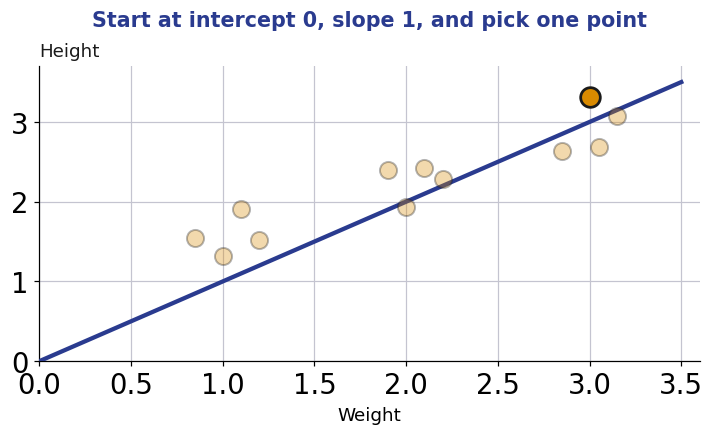

In [85]:
fig, ax = plt.subplots(figsize=(6.8, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 3.6)
ax.set_ylim(0, 3.7)
ax.set_xlabel("Weight", fontsize=12)
ax.text(0, 1.02, "Height", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
xs = np.array([0.0, 3.5])
ax.plot(xs, 0.0 + 1.0 * xs, color=MADRID, lw=2.8, zorder=4)
keep = np.zeros(len(CW), dtype=bool)
keep[[9]] = True                                # this step uses these
ax.scatter(CW[~keep], CH[~keep], s=125, color=ACCENT, edgecolors=INK,
           lw=1.3, zorder=4, alpha=0.32)
ax.scatter(CW[keep], CH[keep], s=165, color=ACCENT, edgecolors=INK,
           lw=1.8, zorder=6)
ax.set_title("Start at intercept 0, slope 1, and pick one point", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### Terminology Alert: the Schedule

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:14px 20px; margin-top:10px;">
<b style="color:#73000A;">TERMINOLOGY ALERT!!!</b><br>
Stochastic gradient descent is just as sensitive to the learning rate as regular gradient descent, and the same strategy applies: start relatively large and make it smaller with each step.<br><br>The way the learning rate changes from large to small is called the <b style="color:#73000A;">schedule</b>.<br><br>So if you fail to converge on parameter estimates, that is the setting to go and fiddle with.
</div>


### Where It Lands

Repeat a bunch of times and we end up with

$$\text{intercept} = \mathbf{0.85} \qquad \text{slope} = \mathbf{0.68}$$

Least squares, the gold standard, gives

$$\text{intercept} = \mathbf{0.87} \qquad \text{slope} = \mathbf{0.68}$$


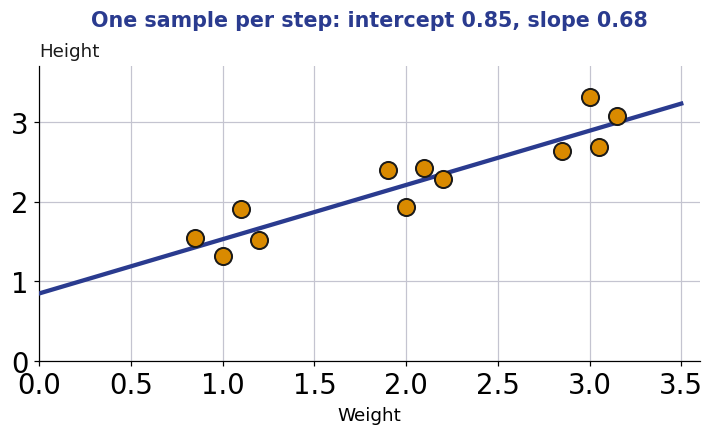

In [86]:
fig, ax = plt.subplots(figsize=(6.8, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 3.6)
ax.set_ylim(0, 3.7)
ax.set_xlabel("Weight", fontsize=12)
ax.text(0, 1.02, "Height", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
xs = np.array([0.0, 3.5])
ax.plot(xs, 0.85 + 0.68 * xs, color=MADRID, lw=2.8, zorder=4)
ax.scatter(CW, CH, s=125, color=ACCENT, edgecolors=INK, lw=1.3, zorder=5)
ax.set_title("One sample per step: intercept 0.85, slope 0.68", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### A Mini-Batch Lands Closer

The strict definition uses one sample per step, but it is far more common to select a small subset, a <b style="color:#73000A;">mini-batch</b>.

With three samples per step the same run gives

$$\text{intercept} = \mathbf{0.86} \qquad \text{slope} = \mathbf{0.68}$$

nearer the gold standard $0.87$ than the single-sample $0.85$.


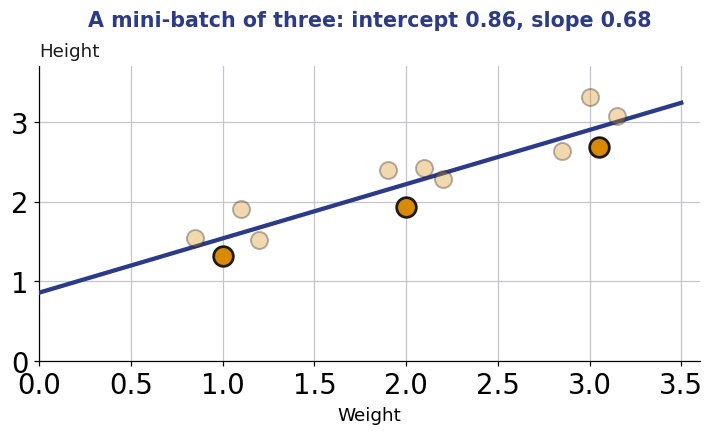

In [87]:
fig, ax = plt.subplots(figsize=(6.8, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 3.6)
ax.set_ylim(0, 3.7)
ax.set_xlabel("Weight", fontsize=12)
ax.text(0, 1.02, "Height", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
xs = np.array([0.0, 3.5])
ax.plot(xs, 0.86 + 0.68 * xs, color=MADRID, lw=2.8, zorder=4)
keep = np.zeros(len(CW), dtype=bool)
keep[[1, 5, 10]] = True                                # this step uses these
ax.scatter(CW[~keep], CH[~keep], s=125, color=ACCENT, edgecolors=INK,
           lw=1.3, zorder=4, alpha=0.32)
ax.scatter(CW[keep], CH[keep], s=165, color=ACCENT, edgecolors=INK,
           lw=1.8, zorder=6)
ax.set_title("A mini-batch of three: intercept 0.86, slope 0.68", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### New Data Without Starting Over

When new data arrives we take another step <b style="color:#73000A;">without starting from scratch</b>. We pick up from the most recent estimate rather than the initial guess.

A new person at weight $1.1$, height $2$, starting from intercept $0.86$ and slope $0.68$:

$$\text{residual} = 2 - (0.86 + 0.68 \times 1.1) = 2 - 1.608 = 0.392$$

$$\frac{d\,\text{SSR}}{d\,\text{intercept}} = -0.784 \qquad \frac{d\,\text{SSR}}{d\,\text{slope}} = -2(1.1)(0.392) = -0.862$$

$$\text{intercept} \to \mathbf{0.868} \qquad \text{slope} \to \mathbf{0.689}$$


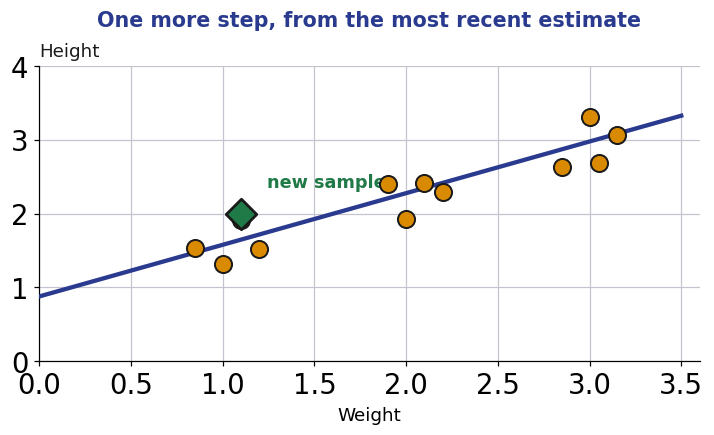

In [88]:
fig, ax = plt.subplots(figsize=(6.8, 4.3), dpi=110)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.grid(True, color=GRIDCOL, lw=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, 3.6)
ax.set_ylim(0, 4.0)
ax.set_xlabel("Weight", fontsize=12)
ax.text(0, 1.02, "Height", transform=ax.transAxes, ha="left", va="bottom",
        fontsize=12, color=INK)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
xs = np.array([0.0, 3.5])
ax.plot(xs, 0.878 + 0.70 * xs, color=MADRID, lw=2.8, zorder=4)
ax.scatter(CW, CH, s=125, color=ACCENT, edgecolors=INK, lw=1.3, zorder=5)
ax.scatter([1.1], [2.0], s=200, color=RING, edgecolors=INK, lw=1.8,
           marker="D", zorder=7)
ax.annotate("new sample", (1.1, 2.0), xytext=(1.2400000000000002, 2.36), fontsize=11.5,
            color=RING, weight="bold")
ax.set_title("One more step, from the most recent estimate", fontsize=13.5, color=MADRID, weight="bold", pad=26)
fig.tight_layout()
plt.show()


### In Summary

Stochastic gradient descent is just like regular gradient descent, except it looks at <b style="color:#73000A;">one sample</b> per step, or a small subset.

It is great when we have <b style="color:#73000A;">tons of data and lots of parameters</b>. In those situations regular gradient descent may not be <b style="color:#73000A;">computationally feasible</b>.

And it is easy to update the parameters when new data shows up.


## Key Ideas

- Fitting a model means minimizing a <b style="color:#73000A;">loss</b>. Sometimes a formula gives the minimum; usually nothing does
- Gradient descent starts from a guess and steps downhill until the steps stop mattering
- The derivative supplies both pieces: its sign is the direction, its size is the distance
- Step Size $=$ Derivative $\times$ Learning Rate, and New $=$ Current $-$ Step Size
- One derivative per parameter; the collection is the <b style="color:#73000A;">gradient</b>
- Stochastic and mini-batch versions trade an exact direction for a cheap step, and let you update on new data
- Downhill finds a bottom, not necessarily the best one


## Check Yourself

1. The derivative of the SSR at your current intercept is $-8$. Which way does the intercept move, and why?
2. Your loss stops falling after 40 steps. Name two different things that could be happening
3. Why does the step size shrink on its own as the walk approaches the bottom, with the learning rate held fixed?
4. Stochastic gradient descent uses one point per step, so each step points in the wrong direction. Why does it still work?


### Answers

1. <b style="color:#73000A;">Up.</b> New $=$ Current $-$ Step Size, and the step size is $-8 \times$ learning rate, which is negative. Subtracting a negative moves the intercept up. A negative derivative always means the bottom lies to the right
2. You have converged; or the step size fell below the minimum without converging; or you hit the maximum number of steps. The stopping rule has both conditions
3. The derivative is the step, up to the learning rate. Near the bottom the tangent flattens, so the derivative shrinks, so the step shrinks. Nothing schedules this
4. Real data is redundant. One point stands in for its neighbours, so each cheap step is approximately right, and the errors average out
